## What we'll be analysing
### 1. **Demographics**
   - What is the distribution of age across the dataset? Are there notable trends or clusters?

### 2. **Education and Income**
   - How does the level of education affect income? Are individuals with higher education levels more likely to earn more?

### 3. **Gender Disparity**
   - Are there significant differences in income distribution between genders (`sex`)?

### 4. **Occupation Trends**
   - What are the most common occupations? Do certain occupations have a higher percentage of high-income earners? 

### 5. **Capital Gains and Losses**
   - How do `capital-gain` and `capital-loss` differ among income groups? Are they significant factors in predicting high income?

### 6. **Marital Status**
   - Does marital status (`marital-status`) influence income? Are married individuals more likely to earn more?

### 7. **Race and Income**
   - Are there noticeable income disparities across different races (`race`)? 

### 8. **Workclass**
   - What is the distribution of individuals across different work classes (`workclass`)? Are private-sector employees earning more than public-sector or self-employed individuals?

### 9. **Age and Income**
   - Is there a specific age range that correlates strongly with higher income? What does the income trend look like over a lifetime?

### 10. **Relationship**
   - How does the relationship category (`relationship`) correlate with income? For example, do "Husband" or "Wife" roles correlate with higher earnings compared to others?

### 11. **Education-Num Analysis**
   - How does the numeric representation of education (`education-num`) compare to `education`? Are they consistent in predicting income?

### 12. **High-Income Predictors**
   - What are the strongest predictors of high income in this dataset? You can use machine learning models to analyze this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 

In [4]:
# Fetch the dataset
income = fetch_ucirepo(id=2)

# Obtain the features & targets
x = income.data.features 
y = income.data.targets 

# List the column names for features and targets from the dataset directly
print("Feature Columns:")
print(x.columns.tolist())  # x contains the features

print("\nTarget Column:")
print(y.columns.tolist())  # y is a DataFrame; this will give the column name(s)

Feature Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Target Column:
['income']


In [5]:
# Combine the features and target into a single DataFrame
original_df = pd.concat([x, y], axis=1)

In [6]:
# Data overview
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
original_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Checking for missing values
original_df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [9]:
original_df.duplicated().sum()

29

In [10]:
# Drop duplicate rows
original_df = original_df.drop_duplicates()

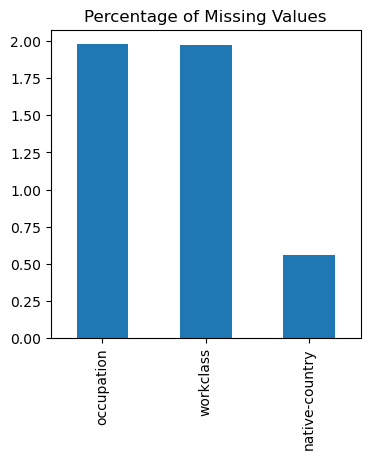

In [11]:
# Visualize missing data percentage
missing_data=original_df.isnull().sum()/len(original_df)*100
missing_data = missing_data[missing_data>0].sort_values(ascending=False)
missing_data.plot(kind='bar', figsize=(4,4))
plt.title("Percentage of Missing Values")
plt.show()

In [12]:
"""
The % of missing values is less so we're dropping the
rows instead of imputing them in order to not distort the analysis
"""
# Remove rows where 'occupation', 'workclass' or 'native-country' is missing
data = original_df.dropna(subset=['occupation', 'workclass', 'native-country'])

In [13]:
# Check if the rows have been removed
print(data.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [14]:
# Clean all columns in the DataFrame to remove extra spaces and unwanted charaters
data = data.applymap(lambda x: str(x).replace(r'[.]', '').strip() if isinstance(x, str) else x)
data['income'] = data['income'].str.replace(r'[.]', '', regex=True).str.strip()

In [15]:
# Fixing the inconsistencies in the dataset
# Under Education, there's HS Grad as well as 12th. So both can be combined
data['education'] = data['education'].replace({'12th': 'HS-grad'})
data['education'] = data['education'].replace({'HS Grad': 'HS-grad'})

# Exploratory Data Analysis

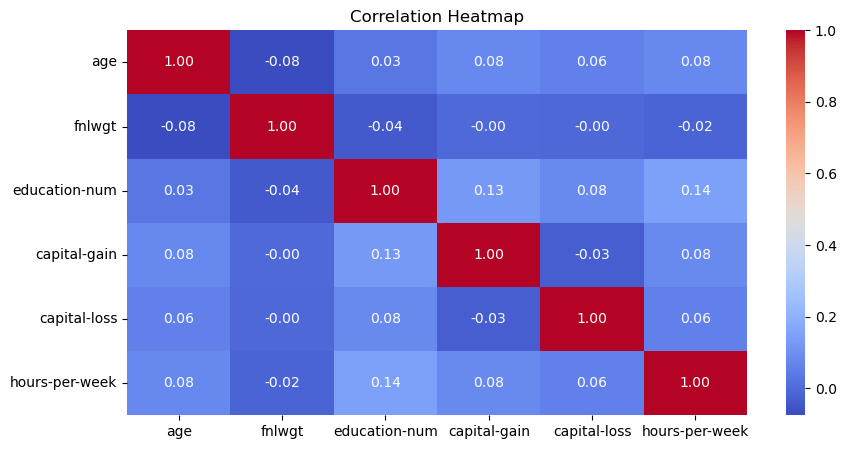

In [16]:
# Exclude non-numeric columns before calculating the correlation matrix
numeric_data = data.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Fill NaN values in correlation matrix with 0 (if necessary)
correlation_matrix = correlation_matrix.fillna(0)

# Plot the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


### What is the distribution of age across the dataset? Are there notable trends or clusters?

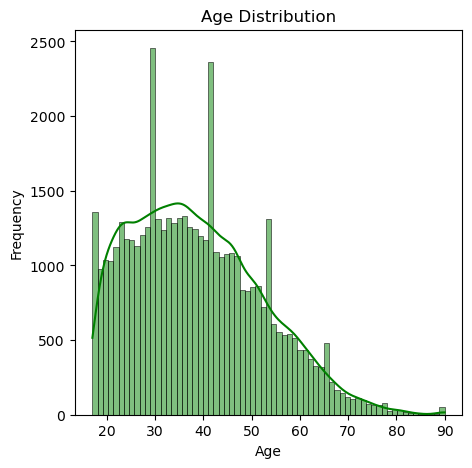

In [17]:
# Age Distribution
plt.figure(figsize=(5,5))
sns.histplot(data['age'], kde=True, color='green')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The most common age groups seem to be 21 to 36, with frequency counts around 900-1300 individuals. 
This suggests that the dataset is predominantly made up of younger individuals, possibly reflecting a more 
active or workforce-oriented demographic.

There is a significant drop in frequency in the higher age groups, especially from ages 70-90 where the 
frequency drastically declines to less than 50 in most cases. This suggests that the dataset is skewed towards 
younger people and may not be as representative of older age groups.

The age groups 86, 87, 89, and 90 have very few individuals.

The age distribution appears to be somewhat skewed toward younger individuals with a majority of ages 
clustered between 17-50 years. This is typical in many workforce-related datasets where younger individuals 
are more likely to be employed, especially for datasets that track income and occupation.

### Income Distribution

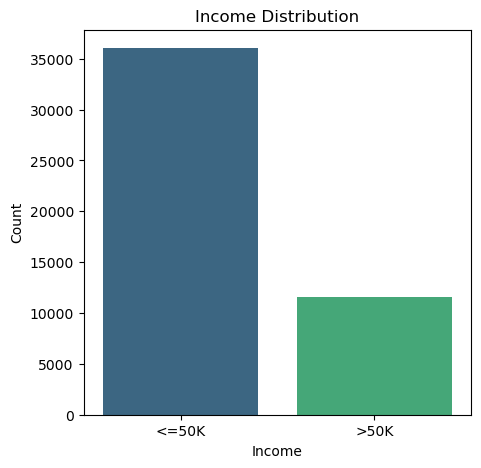

In [18]:
plt.figure(figsize=(5,5))
sns.countplot(x='income', data=data, palette='viridis')
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

In [19]:
income_counts = data['income'].value_counts()
print(income_counts)

income
<=50K    36053
>50K     11539
Name: count, dtype: int64


A majority of the individuals in the dataset earn less than or equal to 50K (<=50K), with 34,428 individuals in this category.
The dataset shows an income imbalance, where the number of individuals earning less than or equal to 50K is significantly higher than those earning more than 50K.
This could indicate that the majority of the population in the dataset has lower income, which may need to be considered when performing any modeling or predictive analysis to account for this imbalance.
Since a large portion of individuals falls in the <=50K category, it’s important to keep this in mind when performing any analysis, especially when analyzing income disparities based on other features like education, occupation, or gender.

### How does the level of education affect income? Are individuals with higher education levels more likely to earn more?

In [20]:
# Mapping and grouping the different education levels into appropriate categories
education_mapping = {
    '5th-6th': 'Lower education',
    '7th-8th': 'Lower education',
    '9th': 'Lower education',
    '10th': 'Lower education',
    '11th': 'Lower education',
    'HS-grad': 'High school',
    '12th': 'High school',
    'Some-college': 'Some college',
    'Bachelors': 'Bachelor\'s degree',
    'Masters': 'Master\'s degree',
    'Doctorate': 'Doctorate',
    'Prof-school': 'Professional school',
    'Assoc-acdm': 'Associate degree',
    'Assoc-voc': 'Associate degree',
    '1st-4th': 'Lower education',
    'Preschool': 'Preschool'
}

# Apply the mapping to the 'education' column
data['education'] = data['education'].map(education_mapping)

# Check the result to ensure the grouping was applied correctly
print(data['education'].value_counts())


education
High school            16069
Some college           10503
Bachelor's degree       7876
Lower education         5458
Associate degree        3599
Master's degree         2609
Professional school      819
Doctorate                582
Preschool                 77
Name: count, dtype: int64


In [21]:
# Define the custom order of education levels
education_order = [
    'Preschool', 'Lower education', 'High school', 'Some college', 
    "Bachelor's degree", "Master's degree", 'Associate degree', 'Doctorate', 'Professional school'
]

# Convert the 'education' column to a categorical type with the custom order
data['education'] = pd.Categorical(data['education'], categories=education_order, ordered=True)

# Sort the data by education in increasing order
data_sorted = data.sort_values(by='education')

# Display the sorted data
print(data_sorted[['education']].head())

       education
39999  Preschool
43515  Preschool
25113  Preschool
11360  Preschool
46143  Preschool


Text(0, 0.5, 'Count')

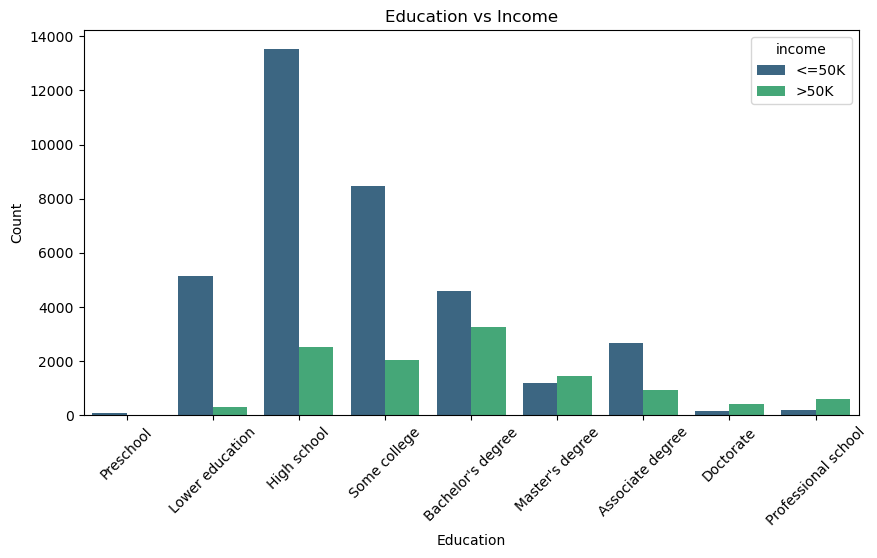

In [22]:
# Education vs Income
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=data, palette='viridis')
plt.title("Education vs Income")
plt.xlabel("Education")
plt.xticks(rotation=45)
plt.ylabel("Count")

In [23]:
# Group by 'education' and 'income', then count the occurrences
education_income_counts = data.groupby(['education', 'income']).size().reset_index(name='count')

# Display the result
print(education_income_counts)

              education income  count
0             Preschool  <=50K     76
1             Preschool   >50K      1
2       Lower education  <=50K   5149
3       Lower education   >50K    309
4           High school  <=50K  13549
5           High school   >50K   2520
6          Some college  <=50K   8463
7          Some college   >50K   2040
8     Bachelor's degree  <=50K   4603
9     Bachelor's degree   >50K   3273
10      Master's degree  <=50K   1175
11      Master's degree   >50K   1434
12     Associate degree  <=50K   2671
13     Associate degree   >50K    928
14            Doctorate  <=50K    157
15            Doctorate   >50K    425
16  Professional school  <=50K    210
17  Professional school   >50K    609


Higher education correlates with higher income: Individuals with higher levels of education, such as a Bachelor's degree, Master's degree, and Doctorate, have a higher count in the >50K category. However, there is still a significant proportion of people in each category who earn less than or equal to 50K.

Even in higher education categories like Master's or Doctorate, there are individuals earning less than 50K. This could be due to factors like the industry, experience, or job role, showing that education alone isn't always a perfect predictor of income.

### Are there significant differences in income distribution between genders?

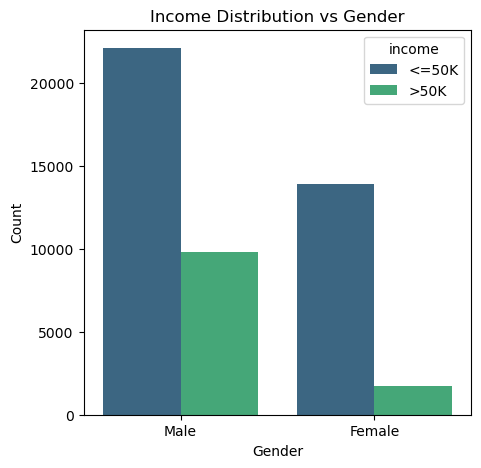

      sex income  count
0  Female  <=50K  13938
1  Female   >50K   1736
2    Male  <=50K  22115
3    Male   >50K   9803


In [24]:
plt.figure(figsize=(5,5))
sns.countplot(x='sex', hue='income', data=data, palette='viridis')
plt.title("Income Distribution vs Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Group by 'education' and 'income', then count the occurrences
gender_income_counts = data.groupby(['sex', 'income']).size().reset_index(name='count')

# Display the result
print(gender_income_counts)

A significant majority of females (about 89%) earn less than or equal to 50K, with only a smaller proportion (about 11%) earning more than 50K.

Similarly, the majority of males (about 69%) earn less than or equal to 50K, but a larger proportion (about 31%) of males earn more than 50K compared to females.

The dataset reveals a gender income disparity, with males having a higher proportion of high-income earners (>50K) compared to females. This could be indicative of gender inequality in terms of access to high-paying job roles, career progression, or other social and economic factors that influence income.

### What are the most common occupations? Do certain occupations have a higher percentage of high-income earners?

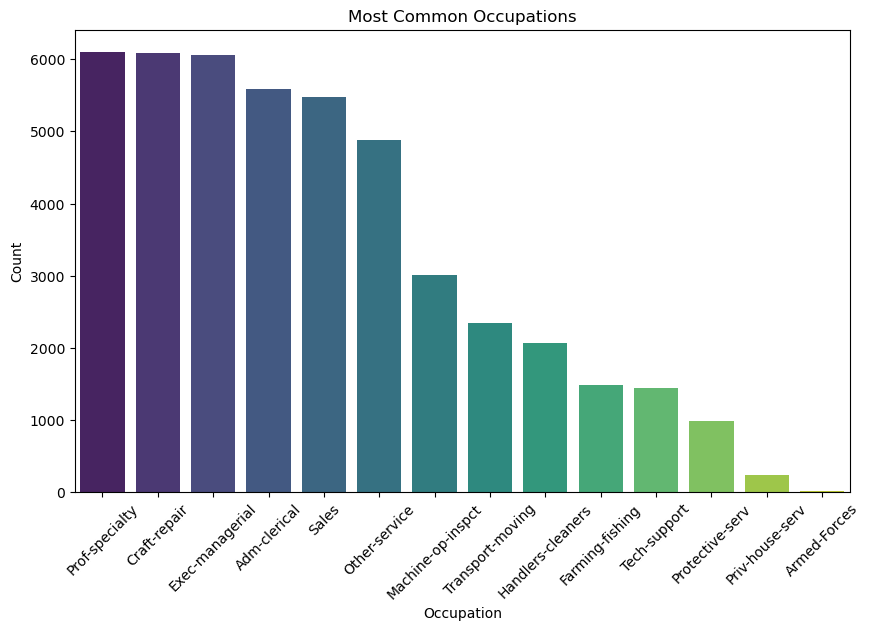

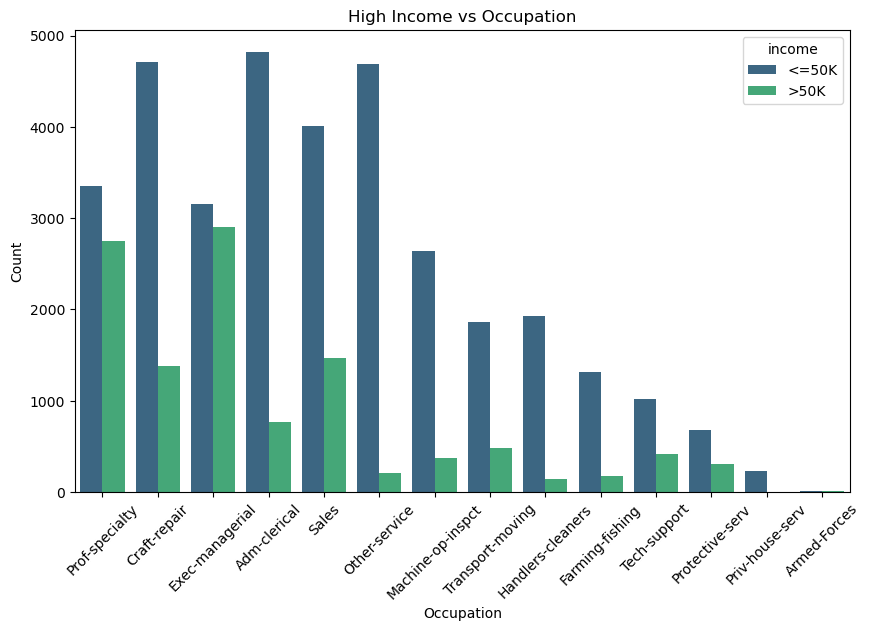

occupation
Prof-specialty       6105
Craft-repair         6084
Exec-managerial      6056
Adm-clerical         5586
Sales                5474
Other-service        4887
Machine-op-inspct    3003
Transport-moving     2341
Handlers-cleaners    2065
Farming-fishing      1482
Tech-support         1435
Protective-serv       981
Priv-house-serv       236
Armed-Forces           14
Name: count, dtype: int64


In [25]:
# Most Common Occupations
# Drop rows where 'occupation' is '?'
data = data[data['occupation'] != '?']

plt.figure(figsize=(10, 6))
sns.countplot(x='occupation', data=data, order=data['occupation'].value_counts().index, palette='viridis')
plt.title('Most Common Occupations')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# High Income vs Occupation
plt.figure(figsize=(10, 6))
sns.countplot(x='occupation', hue='income', data=data, order=data['occupation'].value_counts().index, palette='viridis')
plt.title('High Income vs Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(data['occupation'].value_counts())

In [26]:
data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelor's degree,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelor's degree,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,High school,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,Lower education,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelor's degree,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


The dataset is skewed towards professions in professional specialties, craft repair, and executive/managerial roles, which are common and typically higher-paying sectors.
Service and labor-intensive jobs make up a considerable portion of the dataset, which could indicate a diverse workforce with a broad range of income and skill levels.
Occupations like Armed-Forces and Priv-house-serv are outliers in terms of their low representation.

### How do capital-gain and capital-loss differ among income groups? Are they significant factors in predicting high income?

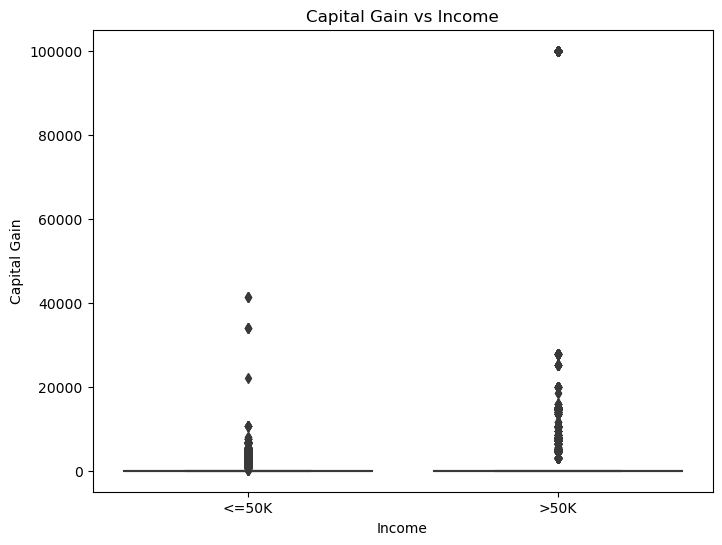

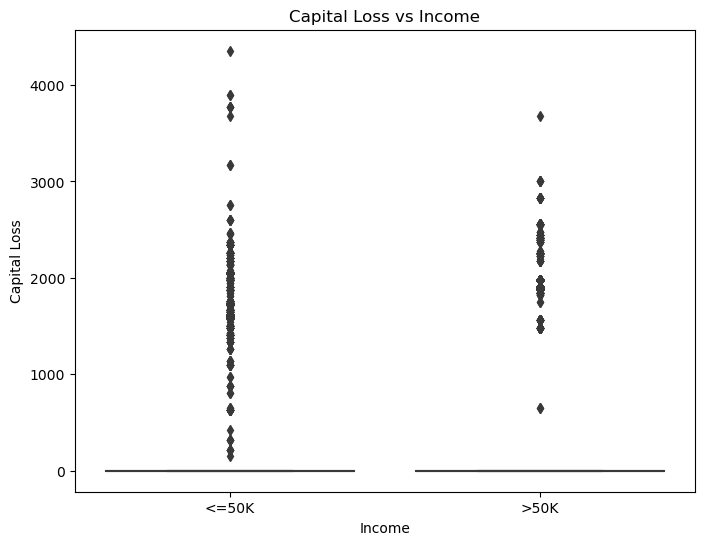

In [27]:
# Capital Gain vs Income
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='capital-gain', data=data, palette='viridis')
plt.title('Capital Gain vs Income')
plt.xlabel('Income')
plt.ylabel('Capital Gain')
plt.show()

# Capital Loss vs Income
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='capital-loss', data=data, palette='viridis')
plt.title('Capital Loss vs Income')
plt.xlabel('Income')
plt.ylabel('Capital Loss')
plt.show()


In [28]:
# Numerical Summary for Capital Gain
capital_gain_summary = data.groupby('income')['capital-gain'].describe()
print("Capital Gain Summary:")
print(capital_gain_summary)

# Numerical Summary for Capital Loss
capital_loss_summary = data.groupby('income')['capital-loss'].describe()
print("\nCapital Loss Summary:")
print(capital_loss_summary)

Capital Gain Summary:
          count         mean           std  min  25%  50%  75%      max
income                                                                 
<=50K   34401.0   148.576727    924.213736  0.0  0.0  0.0  0.0  41310.0
>50K    11348.0  4030.296176  14731.343708  0.0  0.0  0.0  0.0  99999.0

Capital Loss Summary:
          count        mean         std  min  25%  50%  75%     max
income                                                             
<=50K   34401.0   54.121799  312.370447  0.0  0.0  0.0  0.0  4356.0
>50K    11348.0  194.771854  594.829891  0.0  0.0  0.0  0.0  3683.0


Both income groups have many individuals (<=50K: 34,428, >50K: 11,350), but the high-income group (>50K) is smaller in size.

Mean:
Low-income group (<=50K) has a significantly lower average capital gain (148.46) compared to the high-income group (>50K) with 4029.59.
This indicates that higher-income individuals are more likely to have substantial capital gains.

Standard Deviation:
The high-income group has a much larger standard deviation (14,730.14), showing high variability in capital gains among them.
In contrast, the low-income group has less variability (923.86).

Quartiles (25%, 50%, 75%):
For both groups, the 25%, 50%, and 75% quartiles are all 0, indicating that the majority of individuals in both groups do not report capital gains.
However, a small subset of the high-income group has significant capital gains, reflected in their much higher maximum value (99,999).

Maximum capital loss is higher in the low-income group (4,356) compared to the high-income group (3,683). This might indicate occasional larger losses in the low-income group.

### Does marital status influence income? Are married individuals more likely to earn more?

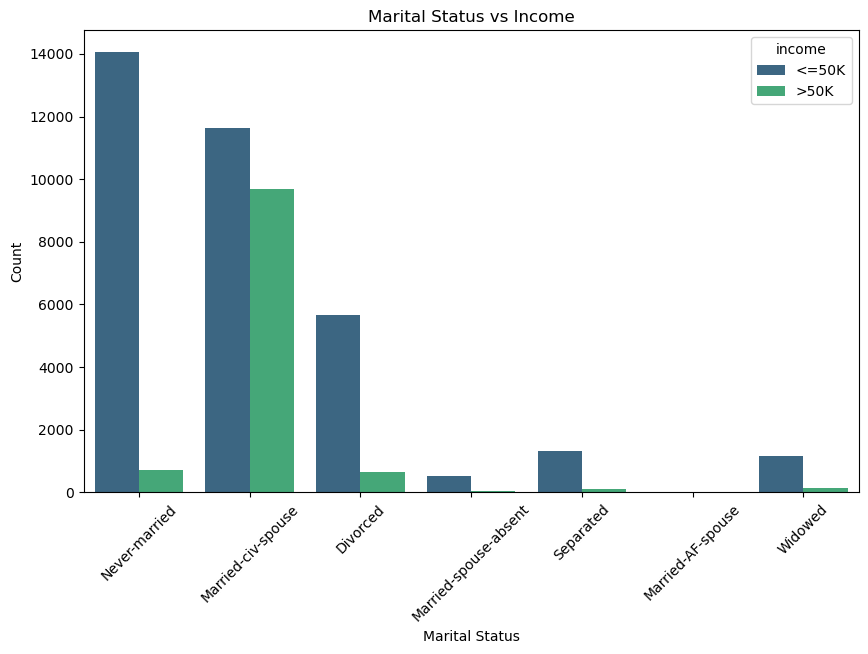

In [29]:
# Marital Status vs Income
plt.figure(figsize=(10, 6))
sns.countplot(x='marital-status', hue='income', data=data, palette='viridis')
plt.title('Marital Status vs Income')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [30]:
marital_income_summary = data.groupby(['marital-status', 'income']).size().reset_index(name='count')
print(marital_income_summary)

           marital-status income  count
0                Divorced  <=50K   5678
1                Divorced   >50K    660
2       Married-AF-spouse  <=50K     18
3       Married-AF-spouse   >50K     14
4      Married-civ-spouse  <=50K  11638
5      Married-civ-spouse   >50K   9684
6   Married-spouse-absent  <=50K    515
7   Married-spouse-absent   >50K     56
8           Never-married  <=50K  14052
9           Never-married   >50K    713
10              Separated  <=50K   1332
11              Separated   >50K     99
12                Widowed  <=50K   1168
13                Widowed   >50K    122


Married-civ-spouse has the highest representation in the >50K income group with 9,686 individuals, making up a significant proportion of higher earners.

Never-married individuals dominate the <=50K group with 14,071 individuals, suggesting a potential link between marital status and income levels.

Categories like Divorced, Separated, and Widowed show higher representation in the <=50K group compared to the >50K group.

Rare categories like Married-AF-spouse and Married-spouse-absent have minimal representation across both income levels.

Marriage, particularly the Married-civ-spouse status, seems to correlate with higher income levels.

Being single, separated, or widowed may correlate with lower income.

Actions Based on Insights:
Explore other variables like education or hours worked for these marital-status groups to identify underlying causes.

### Are there noticeable income disparities across different races (race)?

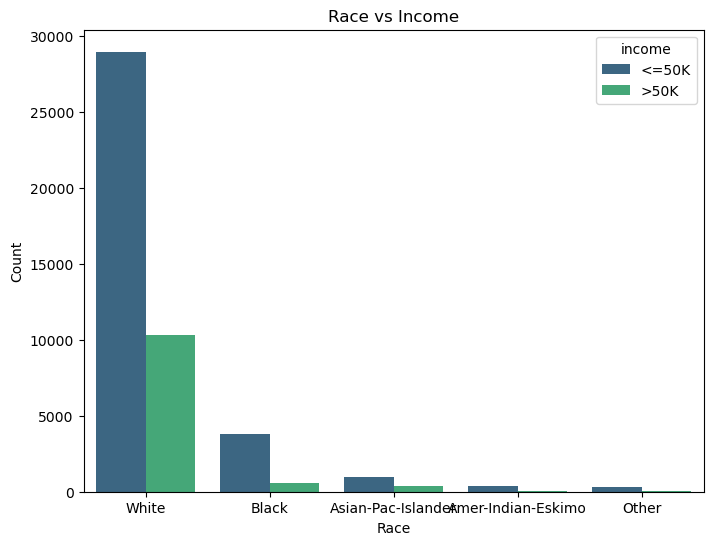

In [31]:
# Race vs Income Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='race', hue='income', data=data, palette='viridis')
plt.title('Race vs Income')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

In [32]:
# Group the data by 'race' and 'income' and get the count
race_income_counts = data.groupby(['race', 'income']).size().reset_index(name='count')

# Print the counts
print(race_income_counts)

                 race income  count
0  Amer-Indian-Eskimo  <=50K    382
1  Amer-Indian-Eskimo   >50K     53
2  Asian-Pac-Islander  <=50K    989
3  Asian-Pac-Islander   >50K    392
4               Black  <=50K   3772
5               Black   >50K    546
6               Other  <=50K    323
7               Other   >50K     47
8               White  <=50K  28935
9               White   >50K  10310


The majority of individuals across all racial categories earn less than or equal to 50K, with the highest count in the White race category.
The number of individuals with income greater than 50K is much lower in all racial categories, but it still shows that more individuals from White, Black, and Asian-Pac-Islander races earn over 50K compared to other groups.

However, it is important to note that
The White race has the largest number of individuals in both income categories, especially in the <=50K category and The Amer-Indian-Eskimo and Other races have the smallest counts in both income categories.

### What is the distribution of individuals across different work classes (workclass)? Are private-sector employees earning more than public-sector or self-employed individuals?

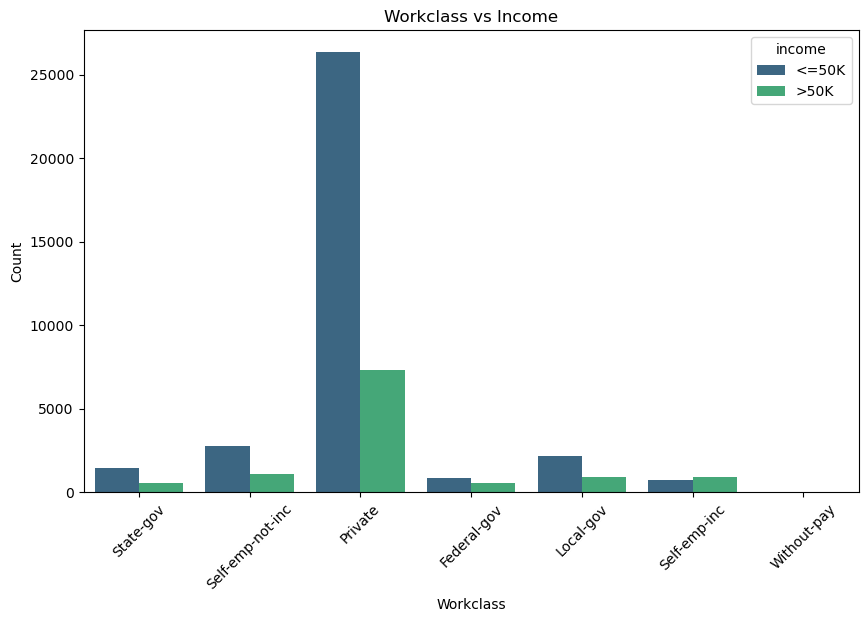

In [33]:
# Workclass vs Income Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='workclass', hue='income', data=data, palette='viridis')
plt.title('Workclass vs Income')
plt.xlabel('Workclass')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [34]:
# Grouping by workclass and income, and counting the occurrences
workclass_income_count = data.groupby(['workclass', 'income']).size().reset_index(name='count')

# Display the result
print(workclass_income_count)

           workclass income  count
0        Federal-gov  <=50K    868
1        Federal-gov   >50K    555
2          Local-gov  <=50K   2203
3          Local-gov   >50K    923
4            Private  <=50K  26354
5            Private   >50K   7336
6       Self-emp-inc  <=50K    753
7       Self-emp-inc   >50K    934
8   Self-emp-not-inc  <=50K   2768
9   Self-emp-not-inc   >50K   1069
10         State-gov  <=50K   1436
11         State-gov   >50K    529
12       Without-pay  <=50K     19
13       Without-pay   >50K      2


Private sector has the highest number of individuals, with a large group earning <=50K but also a substantial number earning >50K.

Self-employed individuals (both incorporated and not incorporated) have a better income distribution, with a larger proportion earning >50K.

Government jobs (Federal, Local, State) are skewed towards individuals earning <=50K.

Without-pay has very few individuals, and most of them earn <=50K.

### Is there a specific age range that correlates strongly with higher income? What does the income trend look like over a lifetime?

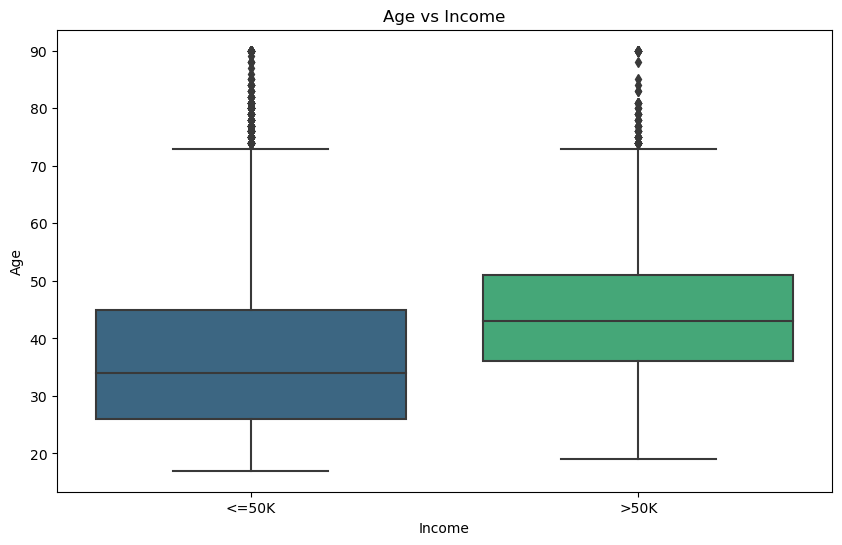

In [35]:
# Age vs Income Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='income', y='age', data=data, palette='viridis')
plt.title('Age vs Income')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

In [36]:
age_income_summary = data.groupby('income')['age'].describe()
print(age_income_summary)

          count       mean        std   min   25%   50%   75%   max
income                                                             
<=50K   34401.0  36.754426  13.547959  17.0  26.0  34.0  45.0  90.0
>50K    11348.0  44.010839  10.337214  19.0  36.0  43.0  51.0  90.0


The mean age for people earning <=50K is lower (36.75 years) compared to those earning >50K (44.01 years).

The age distribution for people earning <=50K is more spread out, with a higher standard deviation (13.55) than those earning >50K (10.34).

The median age for <=50K is 34 years, while for >50K it's 43 years, indicating that higher-income earners tend to be older.

Both groups have ages ranging from 17 to 90 years, but the majority of people in the <=50K group are younger (with the 25th percentile at 26 years, compared to 36 years for the >50K group).

This indicates that individuals with higher incomes tend to be older and possibly have more work experience, while those earning less may have a younger age distribution.

### How does the relationship category (relationship) correlate with income? For example, do "Husband" or "Wife" roles correlate with higher earnings compared to others?

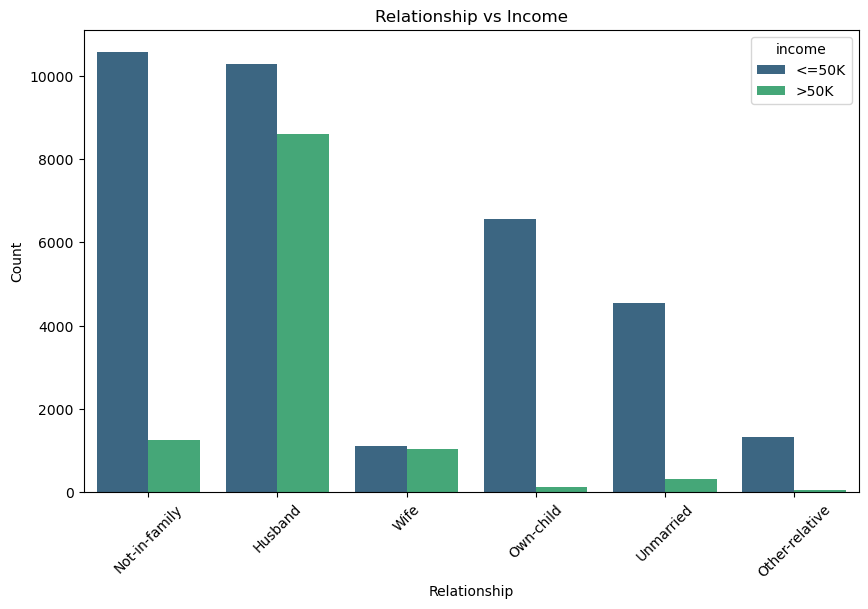

In [37]:
# Relationship vs Income Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='relationship', hue='income', data=data, palette='viridis')
plt.title('Relationship vs Income')
plt.xlabel('Relationship')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [38]:
relationship_income_counts = data.groupby(['relationship', 'income']).size().reset_index(name='count')
print(relationship_income_counts)

      relationship income  count
0          Husband  <=50K  10285
1          Husband   >50K   8615
2    Not-in-family  <=50K  10582
3    Not-in-family   >50K   1243
4   Other-relative  <=50K   1327
5   Other-relative   >50K     51
6        Own-child  <=50K   6573
7        Own-child   >50K    107
8        Unmarried  <=50K   4541
9        Unmarried   >50K    305
10            Wife  <=50K   1093
11            Wife   >50K   1027


Husbands and Wives are the two categories with significant income diversity, with more wives earning above 50K compared to other relationship categories.
Not-in-family and Own-child are the groups where a higher percentage earn less than 50K.
Other-relative shows a very high proportion of individuals earning below 50K, with very few earning above.

This reveals that family-related roles (like husbands and wives) tend to have a broader income range compared to individuals in non-family or child categories, where income is more skewed toward the lower end.

### How does the numeric representation of education (education-num) compare to education? Are they consistent in predicting income?

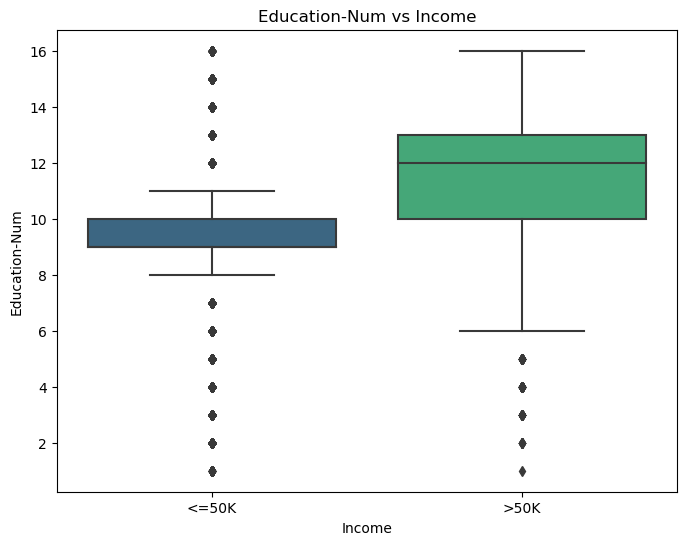

In [39]:
# Education-num vs Income
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='education-num', data=data, palette='viridis')
plt.title('Education-Num vs Income')
plt.xlabel('Income')
plt.ylabel('Education-Num')
plt.show()

In [40]:
# Grouping by 'income' and getting the summary statistics for 'education-num'
education_num_stats = data.groupby('income')['education-num'].describe()

# Displaying the result
print(education_num_stats)

          count       mean       std  min   25%   50%   75%   max
income                                                           
<=50K   34401.0   9.636173  2.427761  1.0   9.0   9.0  10.0  16.0
>50K    11348.0  11.607684  2.374837  1.0  10.0  12.0  13.0  16.0


Higher Education in the >50K Group: On average, individuals with an income greater than 50K have more years of education (11.61 years) compared to those with an income less than or equal to 50K (9.64 years).

Median Education Difference: The median education for the >50K group is 12 years (likely some college or a high school diploma), whereas for the <=50K group, it is 9 years (likely high school or less). This suggests that higher income individuals tend to have higher education levels.

Less Education for Lower-Income Group: The <=50K group has a concentration of individuals with lower levels of education, as seen from the 25th percentile being 9 years, compared to 10 years for the >50K group.

Education Range: Both groups show a broad range of education (from 1 year to 16 years), but the higher income group has slightly higher years of education across the distribution.

Similar Spread: The standard deviation is quite close for both groups, which suggests that the spread or variability in education is not significantly different between the two income groups.

### What are the strongest predictors of high income in this dataset?

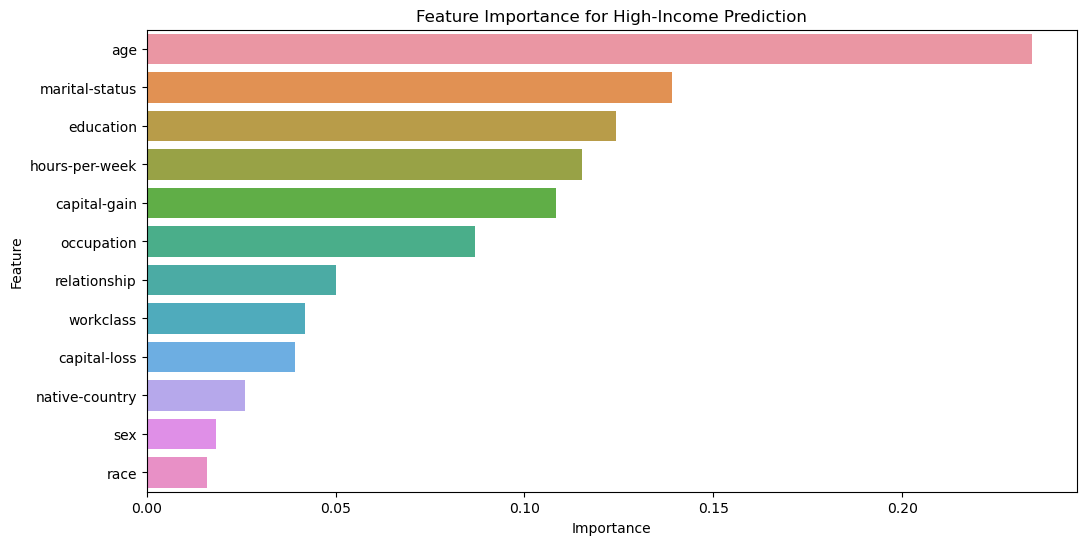

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing: Drop 'fnlwgt' column and convert categorical data to numeric (one-hot encoding)
data_encoded = pd.get_dummies(data.drop('fnlwgt', axis=1), drop_first=True)

# Define target variable and features
X = data_encoded.drop('income_>50K', axis=1)
y = data_encoded['income_>50K']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances and columns
importances = rf.feature_importances_
columns = X.columns

# Group similar one-hot encoded columns (education, workclass, etc.) into the original feature names
grouped_features = []

for col in columns:
    # Identify common categories to group (e.g., education-related columns)
    if col.startswith('education'):
        grouped_features.append('education')
    elif col.startswith('workclass'):
        grouped_features.append('workclass')
    elif col.startswith('native-country'):
        grouped_features.append('native-country')
    elif col.startswith('marital-status'):
        grouped_features.append('marital-status')
    elif col.startswith('occupation'):
        grouped_features.append('occupation')
    elif col.startswith('relationship'):
        grouped_features.append('relationship')
    elif col.startswith('race'):
        grouped_features.append('race')
    elif col.startswith('sex'):
        grouped_features.append('sex')
    elif col.startswith('capital-gain'):
        grouped_features.append('capital-gain')
    elif col.startswith('capital-loss'):
        grouped_features.append('capital-loss')
    elif col.startswith('hours-per-week'):
        grouped_features.append('hours-per-week')
    else:
        grouped_features.append(col)  # For continuous features like age, fnlwgt

# Create a dataframe with feature importances and their corresponding group names
importance_df = pd.DataFrame({
    'Feature': grouped_features,
    'Importance': importances
})

# Group by the feature and sum their importances
importance_df = importance_df.groupby('Feature')['Importance'].sum().reset_index()

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for High-Income Prediction')
plt.show()

In [44]:
# Save the cleaned dataset
data.to_csv('adultIncomeCleaned.csv', index=False)
